In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# =========================================================
# 1) REAPROVEITANDO O MODELO DO PROJETO 1
# =========================================================

def get_rain_data(hours=6):
    url = "https://apps.spaguas.sp.gov.br/sibh/api/v2/measurements/now"
    params = {
        "station_type_id": 1,
        "hours": hours,
        "show_all": "true",
        "serializer": "complete",
        "public": "true"
    }
    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()
    return response.json().get("measurements", [])


def get_level_data():
    url = "https://apps.spaguas.sp.gov.br/sibh/api/v2/measurements/now_flu"
    params = [
        ("references[]", "extravasation"),
        ("references[]", "emergency"),
        ("references[]", "alert"),
        ("references[]", "attention"),
        ("with_one_ref", "true")
    ]
    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()

    data = response.json()
    if isinstance(data, dict):
        for key in ["measurements", "data", "results"]:
            if key in data and isinstance(data[key], list):
                return data[key]
    if isinstance(data, list):
        return data
    return []


def prepare_rain_df(rain_data):
    df = pd.json_normalize(rain_data)

    for col in ["station_name", "city", "value"]:
        if col not in df.columns:
            df[col] = None

    df["rain_value"] = pd.to_numeric(df["value"], errors="coerce")
    keep_cols = [c for c in ["station_name", "city", "rain_value"] if c in df.columns]
    return df[keep_cols].copy()


def prepare_level_df(level_data):
    df = pd.json_normalize(level_data)

    for col in ["station_name", "city", "value", "attention", "alert", "emergency", "extravasation"]:
        if col not in df.columns:
            df[col] = None

    df["level_value"] = pd.to_numeric(df["value"], errors="coerce")
    for ref_col in ["attention", "alert", "emergency", "extravasation"]:
        df[ref_col] = pd.to_numeric(df[ref_col], errors="coerce")

    keep_cols = [c for c in ["station_name", "city", "level_value", "attention", "alert", "emergency", "extravasation"] if c in df.columns]
    return df[keep_cols].copy()


def calculate_level_ratio(row):
    level_value = row.get("level_value", np.nan)
    if pd.isna(level_value):
        return 0.0

    refs = ["attention", "alert", "emergency", "extravasation"]
    score = 0.0

    for ref in refs:
        ref_value = row.get(ref, np.nan)
        if not pd.isna(ref_value) and ref_value != 0:
            score = max(score, level_value / ref_value)

    return min(score, 1.5)


def classify_risk(score):
    if score >= 0.95:
        return "CRÍTICO"
    elif score >= 0.75:
        return "ALTO"
    elif score >= 0.45:
        return "MÉDIO"
    return "BAIXO"


def build_risk_model(hours=6):
    rain_df = prepare_rain_df(get_rain_data(hours))
    level_df = prepare_level_df(get_level_data())

    merged = pd.merge(rain_df, level_df, on=["station_name", "city"], how="outer")

    merged["rain_value"] = merged["rain_value"].fillna(0)
    merged["level_value"] = merged["level_value"].fillna(0)

    max_rain = merged["rain_value"].max() if len(merged) > 0 else 0
    merged["rain_score"] = merged["rain_value"] / max_rain if max_rain > 0 else 0

    merged["level_score"] = merged.apply(calculate_level_ratio, axis=1)
    merged["risk_score"] = merged["rain_score"] * 0.4 + merged["level_score"] * 0.6
    merged["risk_class"] = merged["risk_score"].apply(classify_risk)

    merged = merged.sort_values("risk_score", ascending=False)
    return merged


In [7]:
# =========================================================
# 2) DASHBOARD SIMPLES COM MATPLOTLIB
# =========================================================

def plot_top_risk(df, top_n=15):
    """
    Gera um gráfico simples com as estações mais críticas.
    """
    plot_df = df.head(top_n).copy()

    # Cria rótulo amigável para o eixo Y
    plot_df["label"] = plot_df["station_name"].fillna("Sem nome") + " (" + plot_df["city"].fillna("Sem cidade") + ")"

    plt.figure(figsize=(12, 8))

    # Cores por classe de risco
    color_map = {
        "CRÍTICO": "red",
        "ALTO": "orange",
        "MÉDIO": "gold",
        "BAIXO": "steelblue"
    }
    colors = [color_map.get(r, "gray") for r in plot_df["risk_class"]]

    plt.barh(plot_df["label"], plot_df["risk_score"], color=colors)
    plt.gca().invert_yaxis()

    plt.title("Top Estações por Score de Risco", fontsize=16)
    plt.xlabel("Score de Risco")
    plt.ylabel("Estação")
    plt.grid(axis="x", linestyle="--", alpha=0.4)

    # Escreve o valor do score ao lado da barra
    for i, v in enumerate(plot_df["risk_score"]):
        plt.text(v, i, f" {v:.2f}", va="center")

    plt.tight_layout()
    plt.savefig("dashboard_risco.png", dpi=150)
    plt.show()



In [8]:
# =========================================================
# 3) ALERTAS
# =========================================================

def generate_alerts(df):
    """
    Gera alertas simples em texto.
    """
    critical_df = df[df["risk_class"] == "CRÍTICO"]
    high_df = df[df["risk_class"] == "ALTO"]

    lines = []
    lines.append("RELATÓRIO DE ALERTAS\n")
    lines.append("=" * 50 + "\n")

    lines.append(f"Total de estações analisadas: {len(df)}\n")
    lines.append(f"Estações CRÍTICAS: {len(critical_df)}\n")
    lines.append(f"Estações ALTO risco: {len(high_df)}\n\n")

    if len(critical_df) > 0:
        lines.append("ESTAÇÕES CRÍTICAS:\n")
        for _, row in critical_df.iterrows():
            lines.append(
                f"- {row['station_name']} ({row['city']}) | "
                f"chuva={row.get('rain_value', 0):.2f} | "
                f"nível={row.get('level_value', 0):.2f} | "
                f"score={row.get('risk_score', 0):.2f}\n"
            )
        lines.append("\n")

    if len(high_df) > 0:
        lines.append("ESTAÇÕES DE ALTO RISCO:\n")
        for _, row in high_df.iterrows():
            lines.append(
                f"- {row['station_name']} ({row['city']}) | "
                f"chuva={row.get('rain_value', 0):.2f} | "
                f"nível={row.get('level_value', 0):.2f} | "
                f"score={row.get('risk_score', 0):.2f}\n"
            )
        lines.append("\n")

    with open("alertas_risco.txt", "w", encoding="utf-8") as f:
        f.writelines(lines)

    print("Arquivo salvo: alertas_risco.txt")



Resumo por classe de risco:

risk_class
BAIXO      385
ALTO       159
MÉDIO       94
CRÍTICO      2
Name: count, dtype: int64


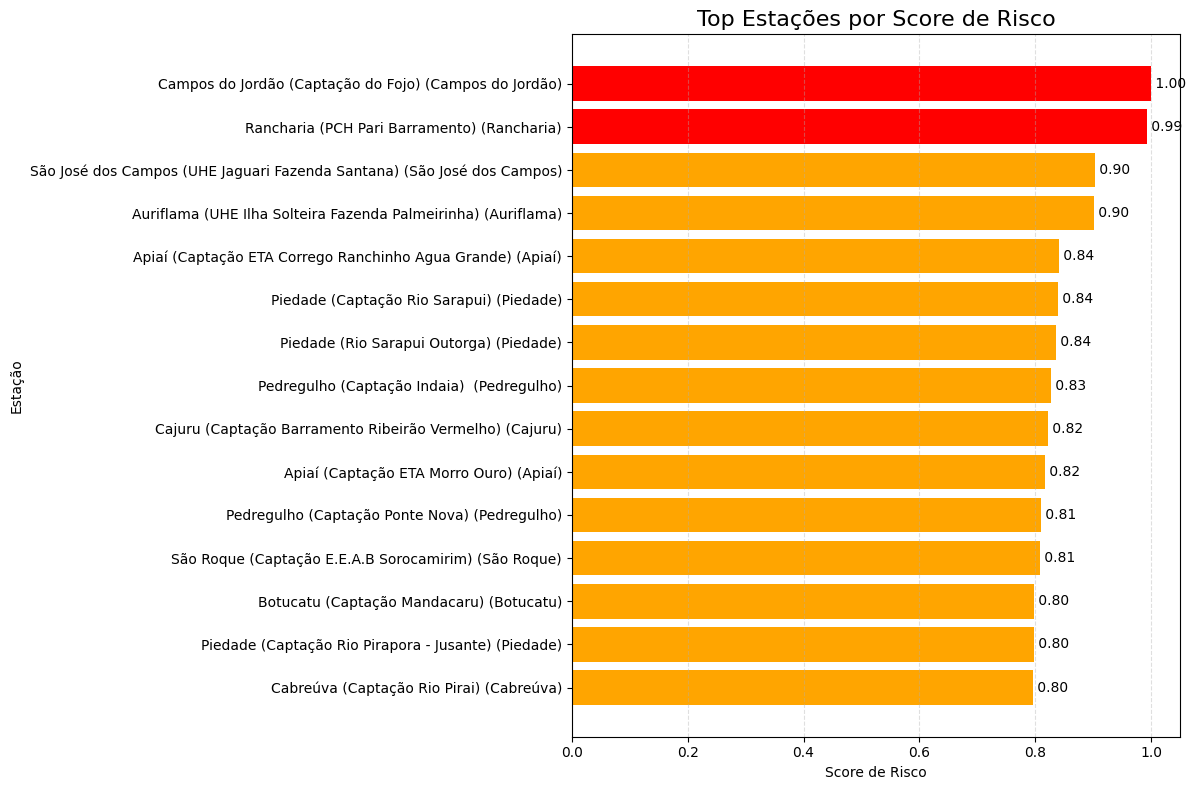

Arquivo salvo: alertas_risco.txt


In [9]:
# =========================================================
# 4) EXECUÇÃO
# =========================================================

if __name__ == "__main__":
    df_risk = build_risk_model(hours=6)

    print("\nResumo por classe de risco:\n")
    print(df_risk["risk_class"].value_counts(dropna=False))

    plot_top_risk(df_risk, top_n=15)
    generate_alerts(df_risk)